# UBA - CEIA - Analisis de Datos


---


# Análisis Exploratorio del Dataset: Crimes 2015 - Chicago

**Fuente:** [City of Chicago Data Portal - Crimes 2015](https://data.cityofchicago.org/Public-Safety/Crimes-2015/vwwp-7yr9/about_data)

Este cuaderno realiza un análisis exploratorio del dataset de crímenes reportados en la ciudad de Chicago durante 2015. El objetivo es identificar sus **características generales** (tamaño, tipo de información, curiosidades y desafíos a priori).

In [1]:
# Librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.max_columns', None)

## 1. Carga de datos

El dataset original está publicado en el portal de datos abiertos de Chicago (Socrata). Como es un dataset grande, se descarga vía la API de Socrata en formato CSV.

> Nota: Socrata limita las consultas por defecto a 1000 filas. Usamos el parámetro `$limit` en la URL para traer mas registros. Si el dataset es muy pesado, también se puede descargar manualmente el CSV desde el portal y subirlo a Colab (opción B alternativa más abajo en la siguinte celda).

In [2]:
# Opción A: Descarga directa desde la API de Socrata
url = "https://data.cityofchicago.org/resource/vwwp-7yr9.csv?$limit=300000"

try:
    df = pd.read_csv(url)
    print("Datos cargados correctamente desde la API.")
except Exception as e:
    print("No se pudo descargar desde la API:", e)
    print("Subí el CSV manualmente con la celda de abajo (Opción B).")

Datos cargados correctamente desde la API.


In [3]:
# Opción B (alternativa): subir el CSV manualmente si la descarga por API falla o es muy lenta
# Descomentar y ejecutar si es necesario

# from google.colab import files
# uploaded = files.upload()
# df = pd.read_csv(list(uploaded.keys())[0])

In [4]:
df.shape

(264903, 22)

In [5]:
df.head()

,id,case_number,date,block,iucr,primary_type,description,location_description,arrest,domestic,beat,district,ward,community_area,fbi_code,x_coordinate,y_coordinate,year,updated_on,latitude,longitude,location
0,10365064,HZ100370,2015-12-31T23:59:00.000,075XX S EMERALD AVE,1320,CRIMINAL DAMAGE,TO VEHICLE,STREET,False,False,621,6,17.0,68.0,14,1172605.0,1854931.0,2015,2018-02-10T15:50:01.000,41.757367,-87.642993,POINT (-87.642992854 41.757366519)
1,10460641,HZ199559,2015-12-31T23:59:00.000,015XX N KEDZIE AVE,0890,THEFT,FROM BUILDING,RESIDENCE PORCH/HALLWAY,False,False,1422,14,26.0,23.0,06,NaN,NaN,2015,2018-02-09T15:44:29.000,NaN,NaN,NaN
2,10364662,HZ100006,2015-12-31T23:55:00.000,079XX S STONY ISLAND AVE,0430,BATTERY,AGGRAVATED: OTHER DANG WEAPON,STREET,False,False,411,4,8.0,45.0,04B,1188223.0,1852840.0,2015,2018-02-10T15:50:01.000,41.751270,-87.585822,POINT (-87.585822373 41.751270452)
3,10364683,HZ100002,2015-12-31T23:50:00.000,037XX N CLARK ST,0460,BATTERY,SIMPLE,SIDEWALK,True,False,1923,19,44.0,6.0,08B,1167786.0,1925033.0,2015,2018-02-10T15:50:01.000,41.949837,-87.658635,POINT (-87.658635101 41.949837364)
4,10364740,HZ100010,2015-12-31T23:50:00.000,024XX W FARGO AVE,0820,THEFT,$500 AND UNDER,APARTMENT,False,False,2411,24,50.0,2.0,06,1158878.0,1949369.0,2015,2018-02-10T15:50:01.000,42.016804,-87.690709,POINT (-87.690708662 42.016804165)


## 2. Características generales del dataset

Tamaño del dataset, tipos de variables (cuantitativas vs categóricas) y estructura general.

In [6]:
print(f"Cantidad de observaciones: {df.shape[0]:,}")
print(f"Cantidad de variables: {df.shape[1]}")
print()
df.info()

Cantidad de observaciones: 264,903
Cantidad de variables: 22

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264903 entries, 0 to 264902
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    264903 non-null  int64  
 1   case_number           264903 non-null  object 
 2   date                  264903 non-null  object 
 3   block                 264903 non-null  object 
 4   iucr                  264903 non-null  object 
 5   primary_type          264903 non-null  object 
 6   description           264903 non-null  object 
 7   location_description  264286 non-null  object 
 8   arrest                264903 non-null  bool   
 9   domestic              264903 non-null  bool   
 10  beat                  264903 non-null  int64  
 11  district              264903 non-null  int64  
 12  ward                  264901 non-null  float64
 13  community_area        264889 non-null  flo

In [7]:
# Clasificación de variables numéricas y categóricas
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=['object', 'bool']).columns.tolist()

print(f"Variables cuantitativas ({len(num_cols)}):")
print(num_cols)
print()
print(f"Variables categóricas ({len(cat_cols)}):")
print(cat_cols)

Variables cuantitativas (10):
['id', 'beat', 'district', 'ward', 'community_area', 'x_coordinate', 'y_coordinate', 'year', 'latitude', 'longitude']

Variables categóricas (12):
['case_number', 'date', 'block', 'iucr', 'primary_type', 'description', 'location_description', 'arrest', 'domestic', 'fbi_code', 'updated_on', 'location']


## 3. Desafíos del dataset

Valores nulos, duplicados y posibles inconsistencias a tener en cuenta antes de analizar los datos.

In [8]:
# Valores nulos por columna
nulls = df.isnull().sum()
nulls = nulls[nulls > 0].sort_values(ascending=False)
nulls_pct = (nulls / len(df) * 100).round(2)

resumen_nulos = pd.DataFrame({'valores_nulos': nulls, '% del total': nulls_pct})
resumen_nulos

,valores_nulos,% del total
x_coordinate,6994,2.64
longitude,6994,2.64
latitude,6994,2.64
y_coordinate,6994,2.64
location,6994,2.64
location_description,617,0.23
community_area,14,0.01
ward,2,0.00


/tmp/ipykernel_4622/2808531943.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=nulls_pct.values, y=nulls_pct.index, palette='Oranges_r')


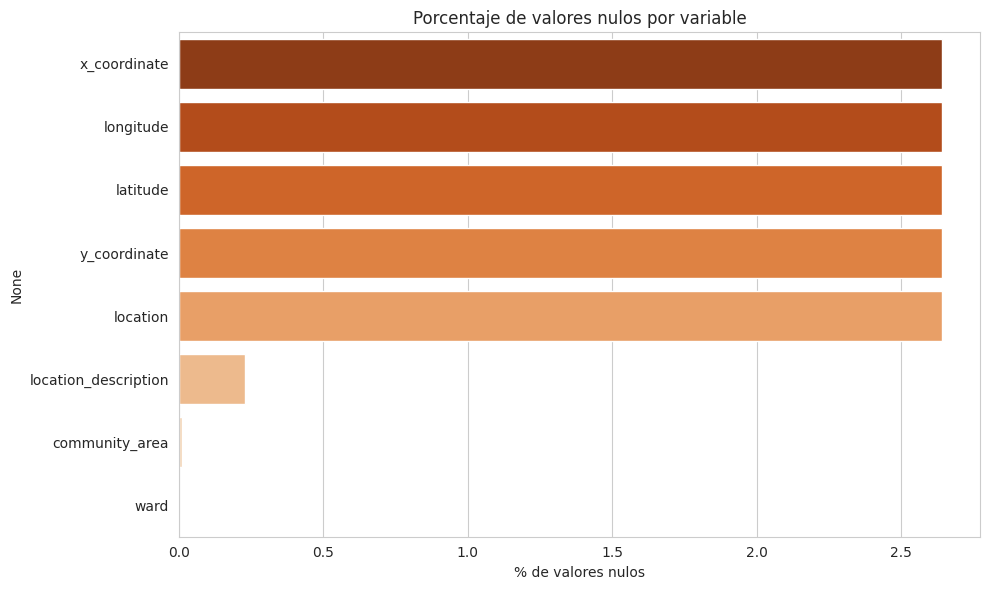

In [9]:
# Gráfico de valores nulos
if len(nulls) > 0:
    plt.figure(figsize=(10, 6))
    sns.barplot(x=nulls_pct.values, y=nulls_pct.index, palette='Oranges_r')
    plt.title('Porcentaje de valores nulos por variable')
    plt.xlabel('% de valores nulos')
    plt.tight_layout()
    plt.show()
else:
    print("No se encontraron valores nulos en el dataset.")

In [10]:
# Duplicados
print(f"Cantidad de filas duplicadas: {df.duplicated().sum()}")

# IDs únicos (chequeo de integridad)
if 'id' in df.columns:
    print(f"IDs únicos: {df['id'].nunique()} de {len(df)} filas")

Cantidad de filas duplicadas: 0
IDs únicos: 264903 de 264903 filas


## 4. Preparación de fechas

Convertimos la columna `date` a formato datetime para poder analizar patrones temporales (hora, día, mes).

In [11]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['hour'] = df['date'].dt.hour
df['day_of_week'] = df['date'].dt.day_name()
df['month'] = df['date'].dt.month

print(f"Rango de fechas: {df['date'].min()} a {df['date'].max()}")

Rango de fechas: 2015-01-01 00:00:00 a 2015-12-31 23:59:00


## 5. Visualizaciones

Gráficos para entender la composición y distribución del dataset, en el mismo espíritu que las diapositivas de ejemplo (barras, torta, dispersión geográfica).

/tmp/ipykernel_4622/1654795971.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_crimes.values, y=top_crimes.index, palette='Blues_r')


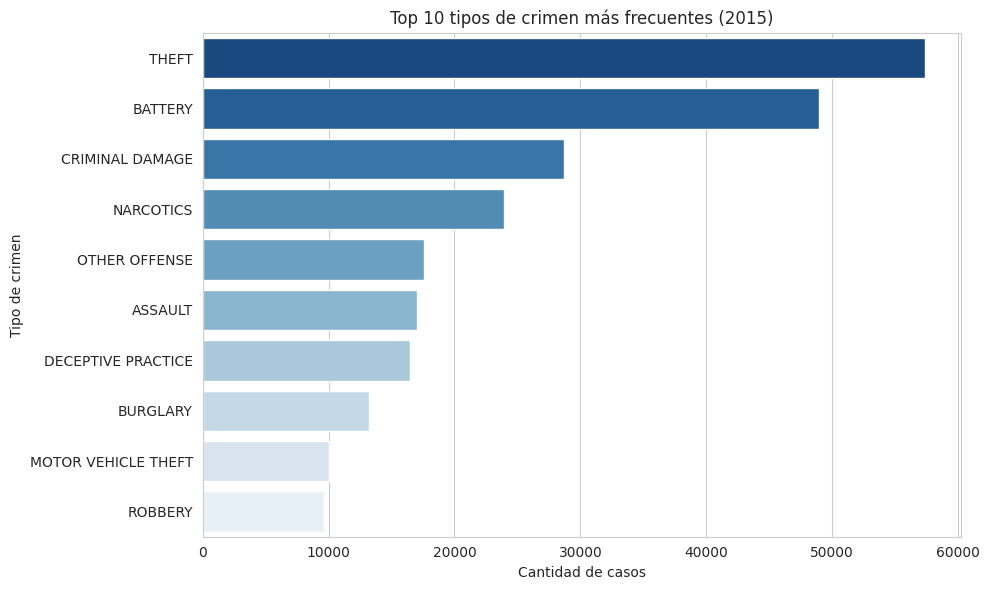

In [12]:
# Top 10 tipos de crimen más frecuentes
top_crimes = df['primary_type'].value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_crimes.values, y=top_crimes.index, palette='Blues_r')
plt.title('Top 10 tipos de crimen más frecuentes (2015)')
plt.xlabel('Cantidad de casos')
plt.ylabel('Tipo de crimen')
plt.tight_layout()
plt.show()

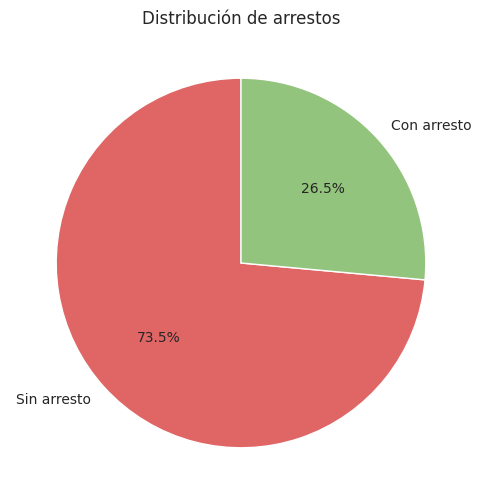

In [13]:
# Distribución de arrestos
arrest_counts = df['arrest'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(arrest_counts.values, labels=arrest_counts.index.map({True: 'Con arresto', False: 'Sin arresto'}),
        autopct='%1.1f%%', colors=['#e06666', '#93c47d'], startangle=90)
plt.title('Distribución de arrestos')
plt.show()

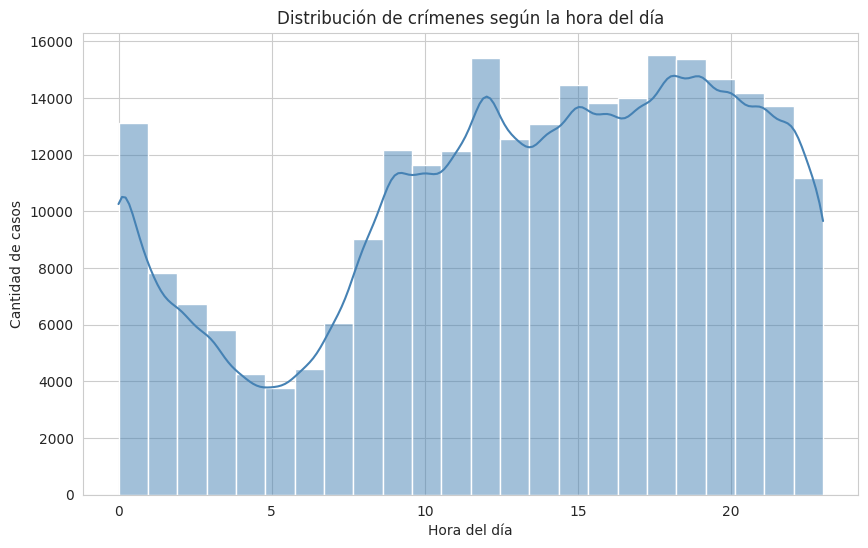

In [14]:
# Distribución de crímenes según la hora del día
plt.figure(figsize=(10, 6))
sns.histplot(df['hour'].dropna(), bins=24, kde=True, color='steelblue')
plt.title('Distribución de crímenes según la hora del día')
plt.xlabel('Hora del día')
plt.ylabel('Cantidad de casos')
plt.show()

/tmp/ipykernel_4622/3437170408.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette='viridis')


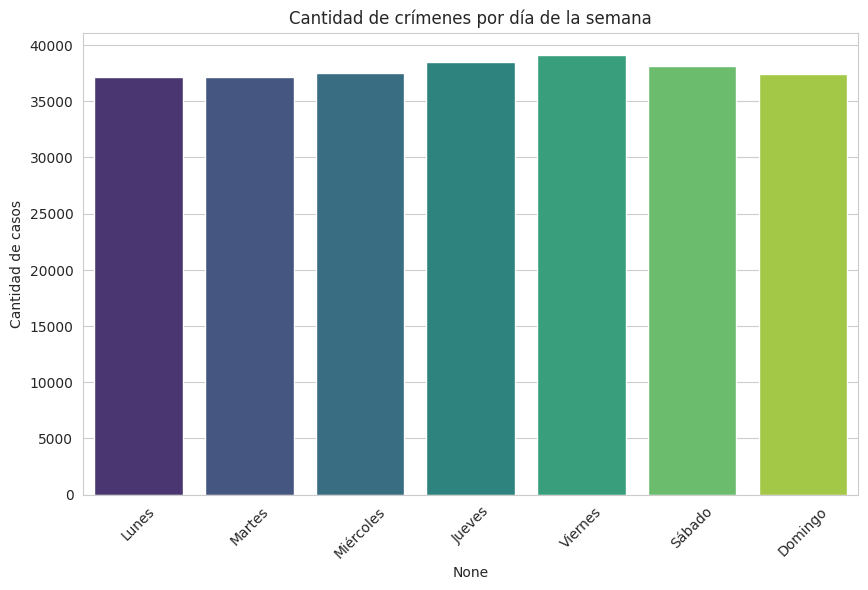

In [15]:
# Crímenes por día de la semana
order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dias_es = {'Monday':'Lunes','Tuesday':'Martes','Wednesday':'Miércoles','Thursday':'Jueves',
           'Friday':'Viernes','Saturday':'Sábado','Sunday':'Domingo'}
counts = df['day_of_week'].value_counts().reindex(order)
counts.index = [dias_es[d] for d in counts.index]

plt.figure(figsize=(10, 6))
sns.barplot(x=counts.index, y=counts.values, palette='viridis')
plt.title('Cantidad de crímenes por día de la semana')
plt.xticks(rotation=45)
plt.ylabel('Cantidad de casos')
plt.show()

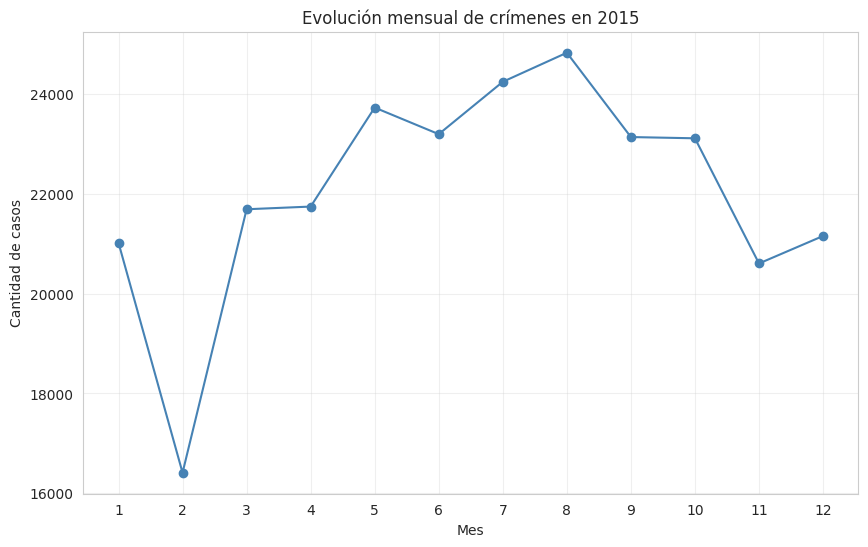

In [16]:
# Evolución mensual de crímenes en 2015
monthly = df['month'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
plt.plot(monthly.index, monthly.values, marker='o', color='steelblue')
plt.title('Evolución mensual de crímenes en 2015')
plt.xlabel('Mes')
plt.ylabel('Cantidad de casos')
plt.xticks(range(1, 13))
plt.grid(True, alpha=0.3)
plt.show()

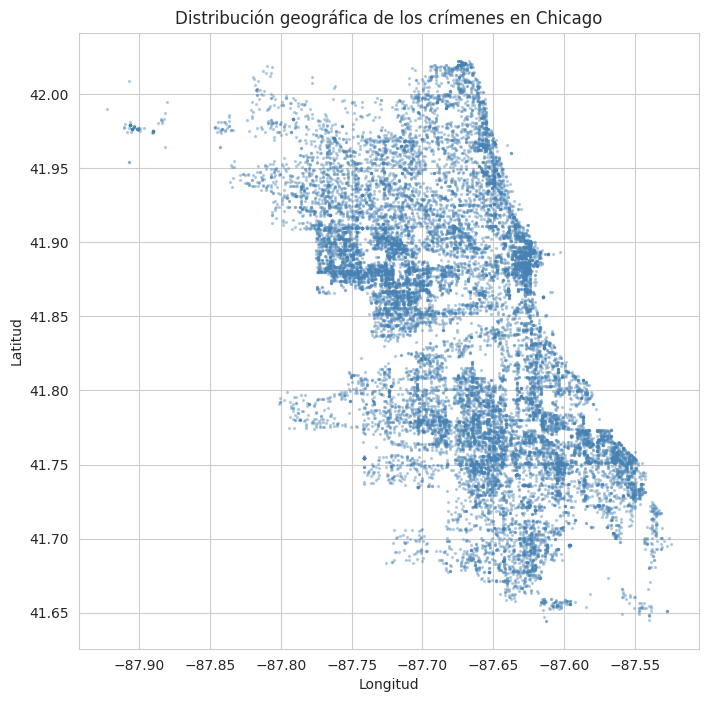

In [17]:
# Distribución geográfica de los crímenes (muestra para no saturar el gráfico)
sample = df.dropna(subset=['latitude', 'longitude'])
sample = sample.sample(min(20000, len(sample)), random_state=42)

plt.figure(figsize=(8, 8))
plt.scatter(sample['longitude'], sample['latitude'], s=2, alpha=0.3, c='steelblue')
plt.title('Distribución geográfica de los crímenes en Chicago')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.show()

/tmp/ipykernel_4622/3937452467.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_areas.values, y=top_areas.index.astype(str), palette='mako')


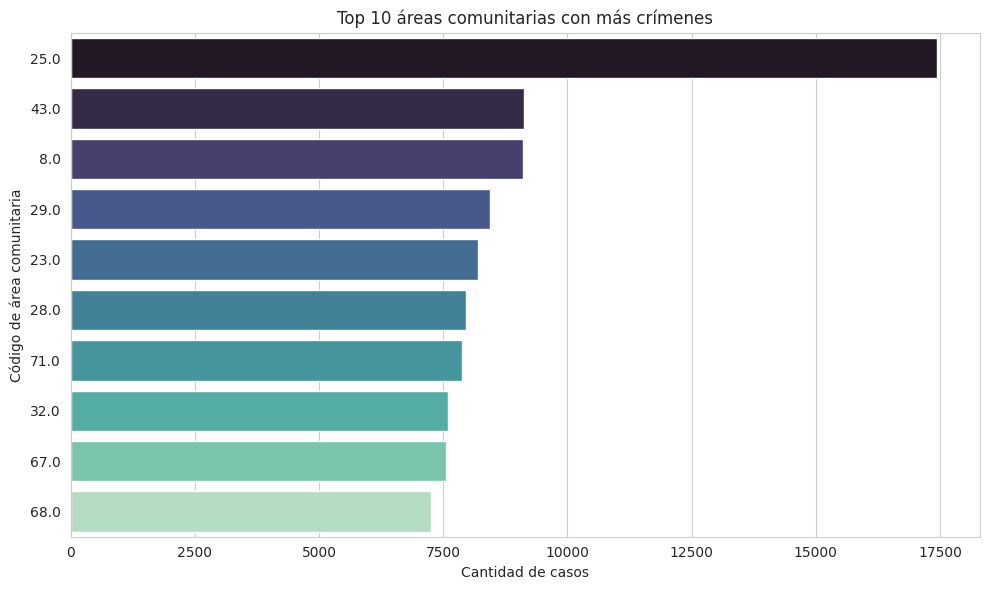

In [18]:
# Top 10 áreas comunitarias / distritos con más crímenes
if 'community_area' in df.columns:
    top_areas = df['community_area'].value_counts().head(10)

    plt.figure(figsize=(10, 6))
    sns.barplot(x=top_areas.values, y=top_areas.index.astype(str), palette='mako')
    plt.title('Top 10 áreas comunitarias con más crímenes')
    plt.xlabel('Cantidad de casos')
    plt.ylabel('Código de área comunitaria')
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_4622/3351809273.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_locations.values, y=top_locations.index, palette='crest')


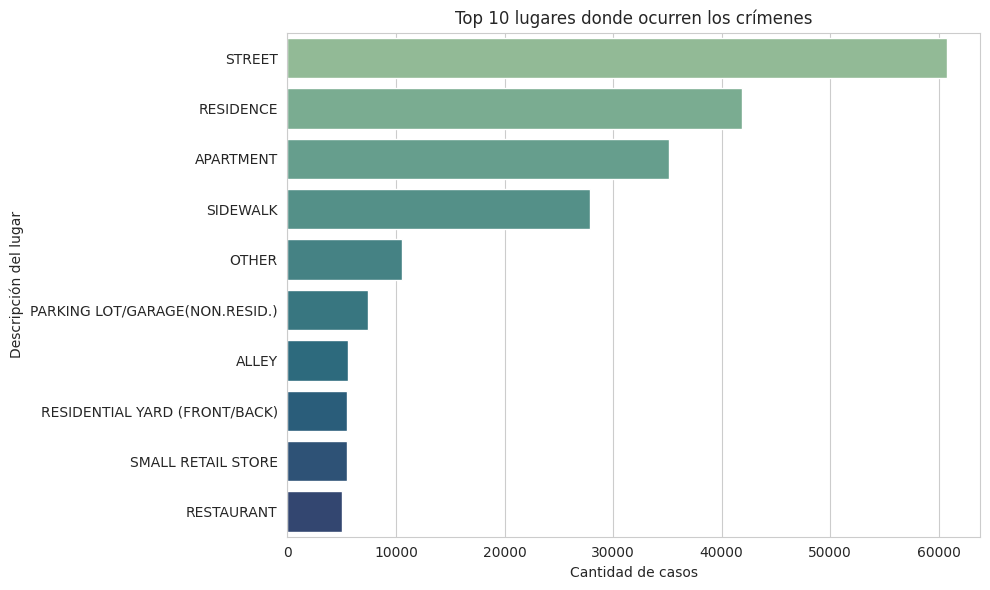

In [19]:
# Top 10 descripciones de ubicación (dónde ocurren los crímenes)
if 'location_description' in df.columns:
    top_locations = df['location_description'].value_counts().head(10)

    plt.figure(figsize=(10, 6))
    sns.barplot(x=top_locations.values, y=top_locations.index, palette='crest')
    plt.title('Top 10 lugares donde ocurren los crímenes')
    plt.xlabel('Cantidad de casos')
    plt.ylabel('Descripción del lugar')
    plt.tight_layout()
    plt.show()

## 6. Resumen para las diapositivas

Esta celda imprime un resumen con los números clave que se pueden usar directamente en las diapositivas (tamaño del dataset, variables, desafíos, curiosidades).

In [20]:
print("="*60)
print("RESUMEN GENERAL - Crimes 2015 Chicago")
print("="*60)
print(f"Observaciones: {df.shape[0]:,}")
print(f"Variables totales: {df.shape[1]}")
print(f"  - Cuantitativas: {len(num_cols)}")
print(f"  - Categóricas: {len(cat_cols)}")
print()
print("Desafíos del dataset:")
for col, pct in nulls_pct.items():
    print(f"  - {pct}% de valores nulos en '{col}'")
print(f"  - Duplicados: {df.duplicated().sum()}")
print()
print("Curiosidades:")
print(f"  - Tipo de crimen más frecuente: {top_crimes.index[0]} ({top_crimes.iloc[0]:,} casos)")
tasa_arresto = (df['arrest'].sum() / len(df) * 100)
print(f"  - Tasa de arresto: {tasa_arresto:.1f}%")
print(f"  - Rango de fechas: {df['date'].min().date()} a {df['date'].max().date()}")
print("="*60)

RESUMEN GENERAL - Crimes 2015 Chicago
Observaciones: 264,903
Variables totales: 25
  - Cuantitativas: 10
  - Categóricas: 12

Desafíos del dataset:
  - 2.64% de valores nulos en 'x_coordinate'
  - 2.64% de valores nulos en 'longitude'
  - 2.64% de valores nulos en 'latitude'
  - 2.64% de valores nulos en 'y_coordinate'
  - 2.64% de valores nulos en 'location'
  - 0.23% de valores nulos en 'location_description'
  - 0.01% de valores nulos en 'community_area'
  - 0.0% de valores nulos en 'ward'
  - Duplicados: 0

Curiosidades:
  - Tipo de crimen más frecuente: THEFT (57,354 casos)
  - Tasa de arresto: 26.5%
  - Rango de fechas: 2015-01-01 a 2015-12-31
